## Zonal Stats for the Voronoi Cells

In this notebook, we are trying to get the zonal stats for the voronoi cells spatial units that are available for the CDR data. 

This is an attempt to homogenize the datasets and bring them to the same scale. This is a zonal statistical approach that will be replaced by the DGGS approach to use hierarchical grid systems to avoid the data conversion. 

In [2]:
## import libraries
import geopandas as gpd
import xarray as xr
import numpy as np
import rioxarray as rio
import pandas as pd
import glob
import os
import re
import time
from datetime import datetime
import scipy
from tqdm import tqdm
from dask import delayed, compute
from dask.diagnostics import ProgressBar
from dask.distributed import Client, LocalCluster

import logging

# import xesmf as xe
import xvec
import ujson
import fsspec
from kerchunk.hdf import SingleHdf5ToZarr
from kerchunk.combine import MultiZarrToZarr

from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import lexcube 
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual

import warnings
warnings.filterwarnings("ignore")
from read_check import*

## Check data and dimensions

In [12]:
# from read_check import check, read, plot

# # Specify the data path directly instead of using input()
# data_path = "/home/kzakir/dvcube/test/data/test_data/testdata1"
# dataset, netcdf_file = read(data_path)
# print(dataset.dims)
# print(dataset.coords)
# print(dataset.data_vars)

# # Then plot a specific variable
# plot(dataset, "METREF")

Opening NetCDF file: /data/dv-data/cdo_processed/NDVI/2010/01/ndvi_20100101_processed.nc
FrozenMappingWarningOnValuesAccess({'time': 1, 'lat': 1001, 'lon': 7501})
Coordinates:
  * time     (time) datetime64[ns] 8B 2010-01-01
  * lat      (lat) float64 8kB 10.0 10.01 10.02 10.03 ... 19.97 19.98 19.99 20.0
  * lon      (lon) float64 60kB -20.0 -19.99 -19.98 -19.97 ... 54.98 54.99 55.0
Data variables:
    NDVI     (time, lat, lon) float32 30MB ...


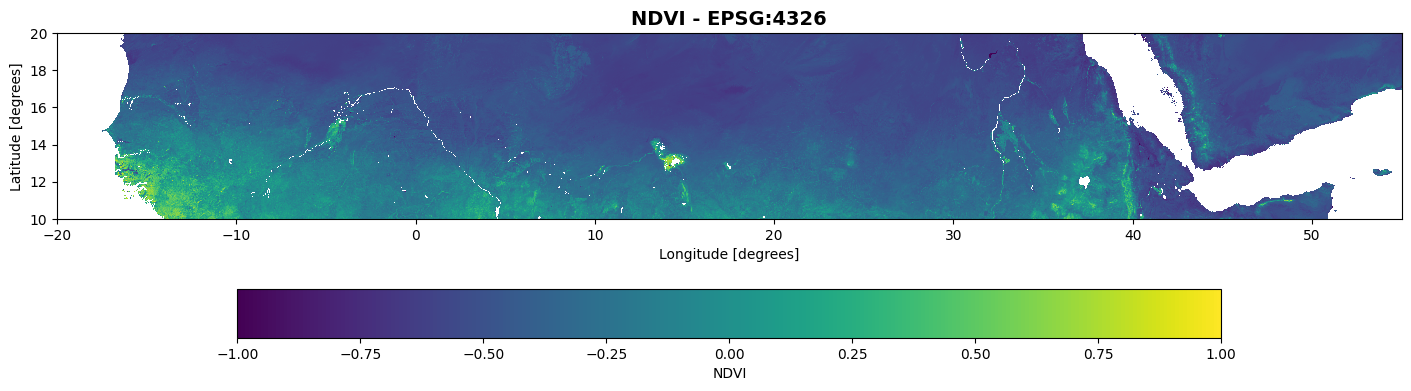

In [17]:
%run /home/kzakir/dvcube/test/cube_example/read_check.py

## Create 1 Kerchunk per file

In [16]:
data_path = Path("/home/kzakir/dvcube/test/data/test_data/testdata1")
out_dir = Path("/home/kzakir/dvcube/test/data/test_data/testdata1/kerchunk_refs/single")

out_dir.mkdir(parents=True, exist_ok=True)

nc_files = sorted(data_path.rglob("*.nc"))
print(f"Found {len(nc_files)} NetCDF files.")

def make_safe_name(path:Path) -> str:
    """Create a safe name for the output JSON file based on the input NetCDF file path."""
    return re.sub(r'[^a-zA-Z0-9]', '_', str(path.relative_to(data_path))) + ".json"

def make_single_ref(nc_path:Path, out_dir:Path) -> Path:
    """Create a single reference JSON file for a given NetCDF file."""
    out_json = out_dir / make_safe_name(nc_path)
    target_url = nc_path.as_uri()  # Convert the path to a file URI

    with fsspec.open(target_url, mode='rb') as f:
        h5chunks = SingleHdf5ToZarr(f, target_url, inline_threshold=300)
        refs = h5chunks.translate()
    with open(out_json, 'w') as f:
        ujson.dump(refs, f)
    return out_json
for i, nc_file in enumerate(nc_files, start=1):
    print(f"Processing file {i}/{len(nc_files)}: {nc_file}")
    make_single_ref(nc_file, out_dir)

print(f"Single reference JSON files created in {out_dir}.")


Found 151 NetCDF files.
Processing file 1/151: /home/kzakir/dvcube/test/data/test_data/testdata1/01/01/NETCDF4_LSASAF_MSG_METREF_MSG-Disk_201001010000.nc
Processing file 2/151: /home/kzakir/dvcube/test/data/test_data/testdata1/01/02/NETCDF4_LSASAF_MSG_METREF_MSG-Disk_201001020000.nc
Processing file 3/151: /home/kzakir/dvcube/test/data/test_data/testdata1/01/03/NETCDF4_LSASAF_MSG_METREF_MSG-Disk_201001030000.nc
Processing file 4/151: /home/kzakir/dvcube/test/data/test_data/testdata1/01/04/NETCDF4_LSASAF_MSG_METREF_MSG-Disk_201001040000.nc
Processing file 5/151: /home/kzakir/dvcube/test/data/test_data/testdata1/01/05/NETCDF4_LSASAF_MSG_METREF_MSG-Disk_201001050000.nc
Processing file 6/151: /home/kzakir/dvcube/test/data/test_data/testdata1/01/06/NETCDF4_LSASAF_MSG_METREF_MSG-Disk_201001060000.nc
Processing file 7/151: /home/kzakir/dvcube/test/data/test_data/testdata1/01/07/NETCDF4_LSASAF_MSG_METREF_MSG-Disk_201001070000.nc
Processing file 8/151: /home/kzakir/dvcube/test/data/test_data/tes

In [9]:
ref_json = "/home/kzakir/dvcube/test/outputs/cdo_output/metref/2010/kerchunk/multi/combined_refs.json"
ds = xr.open_dataset(
    "reference://",
    engine="zarr",
    backend_kwargs={"consolidated": False,
                     "storage_options": {"fo": str(ref_json),
                                         "remote_protocol": "file"},
    },
                                                                         
)

ds

<xarray.Dataset> Size: 24MB
Dimensions:  (time: 5, lat: 201, lon: 1501)
Coordinates:
  * time     (time) datetime64[ns] 40B 2010-01-01 2010-01-02 ... 2010-01-05
  * lat      (lat) float64 2kB 10.0 10.05 10.1 10.15 ... 19.85 19.9 19.95 20.0
  * lon      (lon) float64 12kB -20.0 -19.95 -19.9 -19.85 ... 54.9 54.95 55.0
Data variables:
    var40    (time, lat, lon) float32 6MB ...
    var41    (time, lat, lon) float32 6MB ...
    var42    (time, lat, lon) float32 6MB ...
    var43    (time, lat, lon) float32 6MB ...
Attributes:
    CDI:          Climate Data Interface version 2.0.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Tue Apr 14 10:56:50 2026: cdo -L -f nc4 -z zip_4 -O -remapb...
    CDO:          Climate Data Operators version 2.0.4 (https://mpimet.mpg.de...

In [98]:
if "crs" in ds.data_vars:
    ds = ds.drop_vars("crs")
ds = ds.isel(
    lat = np.where(np.isfinite(ds['lat'].values))[0],
    lon = np.where(np.isfinite(ds['lon'].values))[0]
)

ds = ds.sortby('lat')
ds = ds.sortby('lon')
print(ds.lat.values[:5], ds.lat.values[-5:], ds.lon.values[:5], ds.lon.values[-5:])



[-80.   -79.95 -79.9  -79.85 -79.8 ] [79.8      79.850006 79.90001  79.95     80.      ] [-80.   -79.95 -79.9  -79.85 -79.8 ] [79.8      79.850006 79.90001  79.95     80.      ]


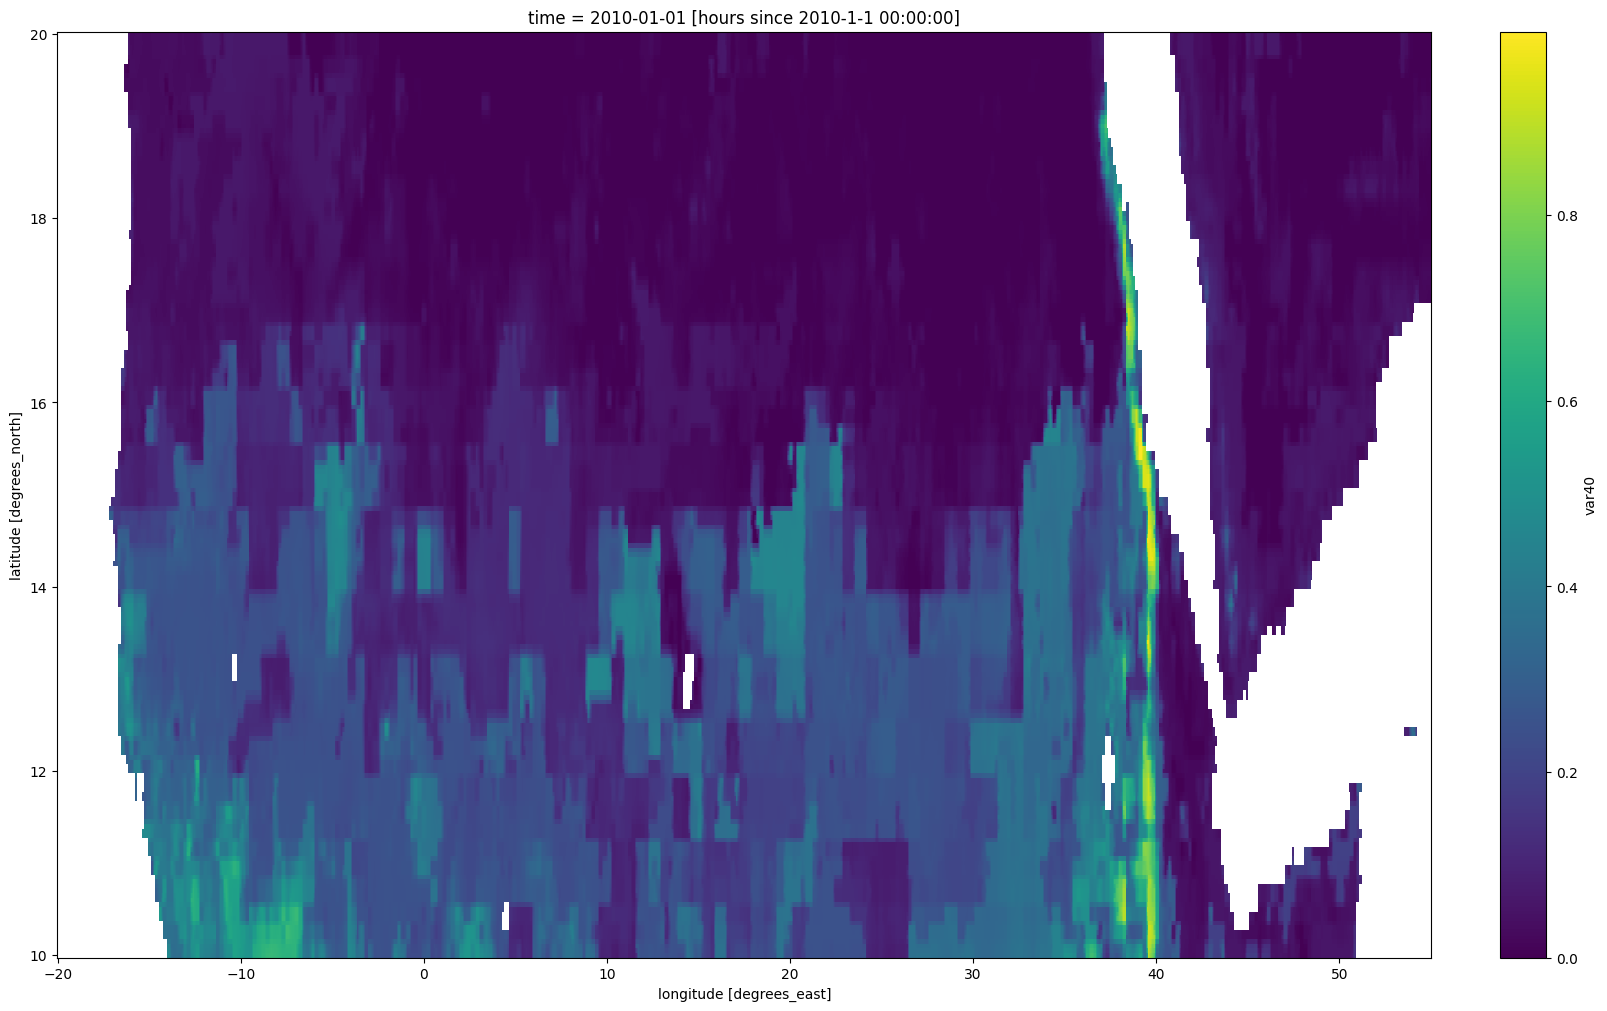

In [10]:
# Calculate aspect ratio for proper geographic display
mean_lat = np.radians(float(ds['lat'].mean()))
# aspect_ratio = 1.0 / np.cos(mean_lat)

fig, ax = plt.subplots(figsize=(16, 10), constrained_layout=True)
ds["var40"].isel(time=0).plot(ax=ax, cmap="viridis")
# ax.set_aspect(aspect_ratio)
plt.show()

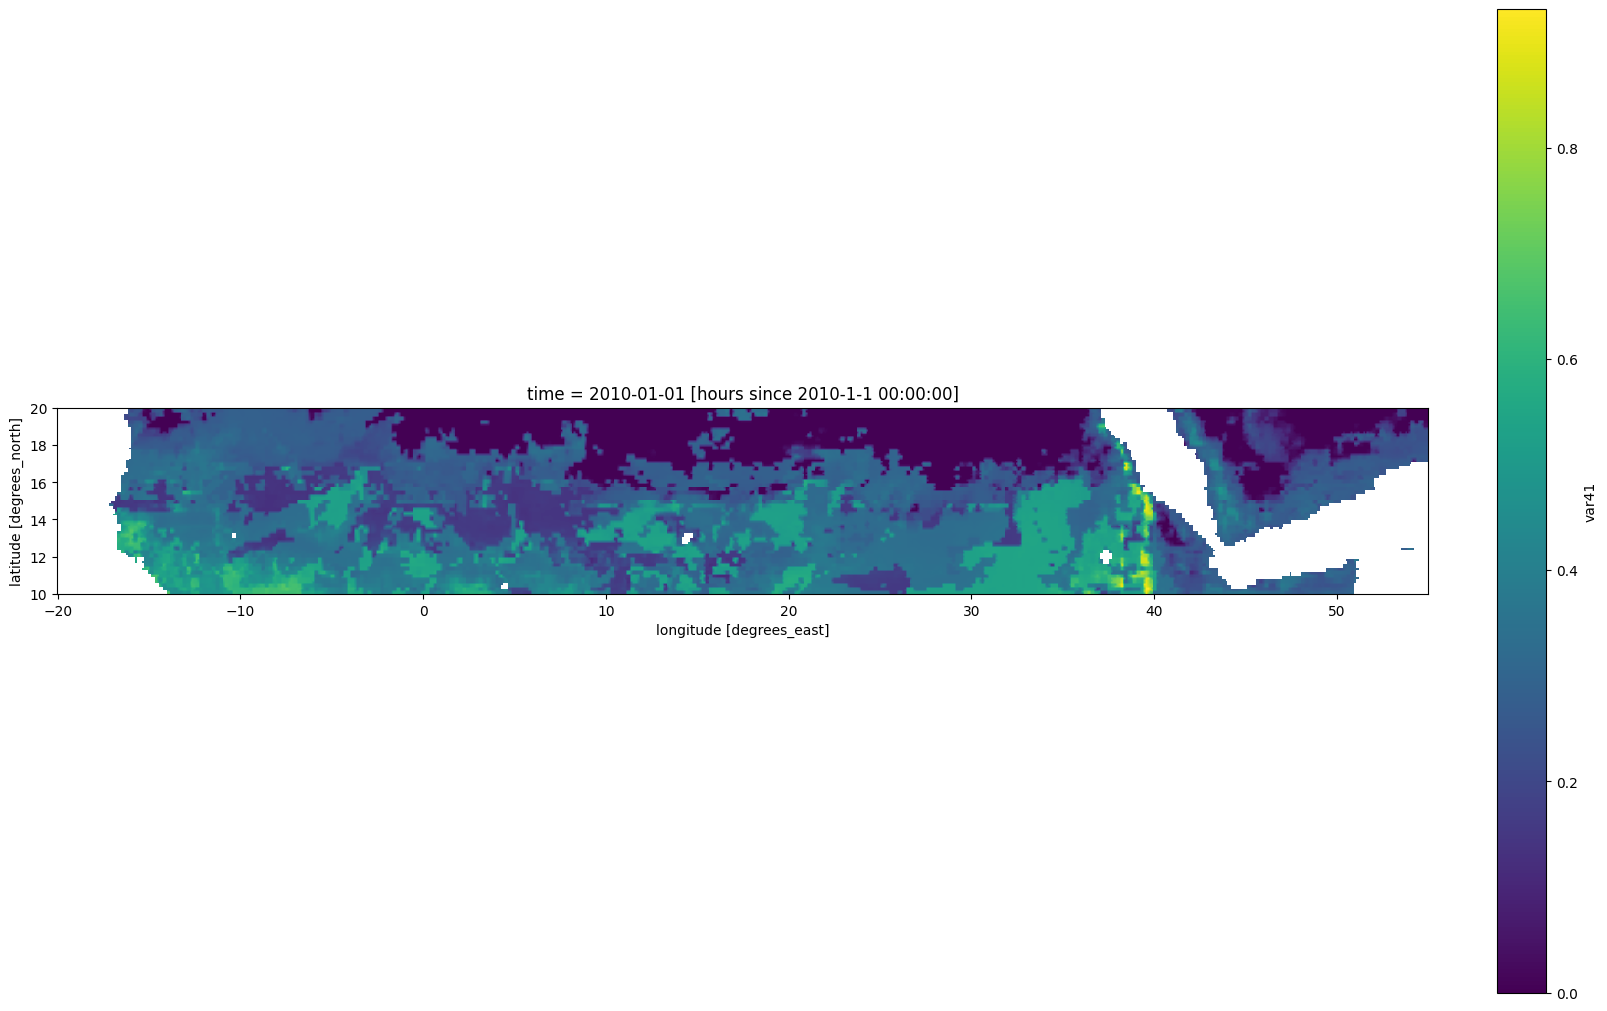

In [14]:
# Calculate aspect ratio for proper geographic display
mean_lat = np.radians(float(ds['lat'].min()))
aspect_ratio = 1.0 / np.cos(mean_lat)

fig, ax = plt.subplots(figsize=(16, 10), constrained_layout=True)
ds["var41"].isel(time=0).plot(ax=ax, cmap="viridis")
ax.set_aspect(aspect_ratio)
plt.show()

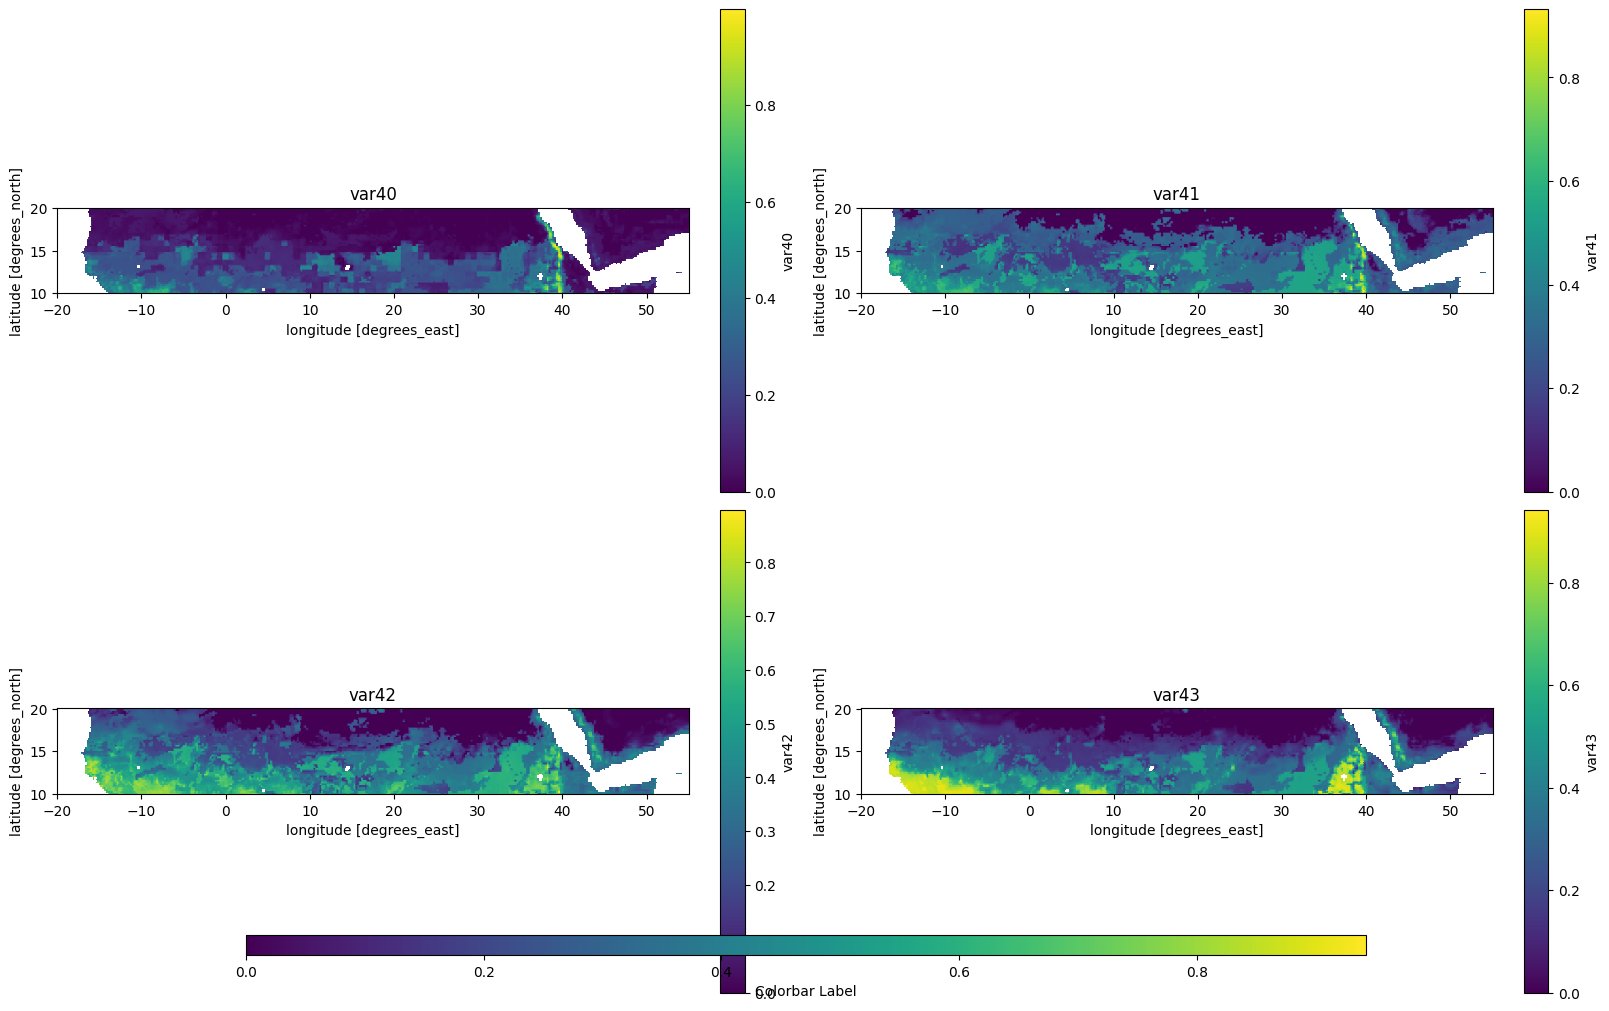

In [64]:
# Calculate aspect ratio for proper geographic display
mean_lat = np.radians(float(ds['lat'].min()))
aspect_ratio = 1.0 / np.cos(mean_lat)

# fig, ax = plt.subplots(figsize=(16, 10), constrained_layout=False)
# ds["var40"].isel(time=0).plot(ax=ax, cmap="viridis")
# ax.set_aspect(aspect_ratio)
# plt.show()
# plot all 4 vars and horizonatal cbar 
fig, axs = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
ds["var40"].isel(time=0).plot(ax=axs[0, 0], cmap="viridis", cbar_kwargs={'label': 'var40'})
axs[0, 0].set_title('var40')
ds["var41"].isel(time=0).plot(ax=axs[0, 1], cmap="viridis", cbar_kwargs={'label': 'var41'})
axs[0, 1].set_title('var41')
ds["var42"].isel(time=0).plot(ax=axs[1, 0], cmap="viridis", cbar_kwargs={'label': 'var42'})
axs[1, 0].set_title('var42')
ds["var43"].isel(time=0).plot(ax=axs[1, 1], cmap="viridis", cbar_kwargs={'label': 'var43'})
axs[1, 1].set_title('var43')

axs[0, 0].set_aspect(aspect_ratio)
axs[0, 1].set_aspect(aspect_ratio)
axs[1, 0].set_aspect(aspect_ratio)
axs[1, 1].set_aspect(aspect_ratio)

#colorbar horizontal
colorbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(axs[1, 1].collections[0], cax=colorbar_ax, orientation='horizontal')
cbar.set_label('Colorbar Label')    
plt.show()

[11.   11.05 11.1  11.15 11.2 ] [17.8  17.85 17.9  17.95 18.  ] [-18.   -17.95 -17.9  -17.85 -17.8 ] [-12.2  -12.15 -12.1  -12.05 -12.  ]


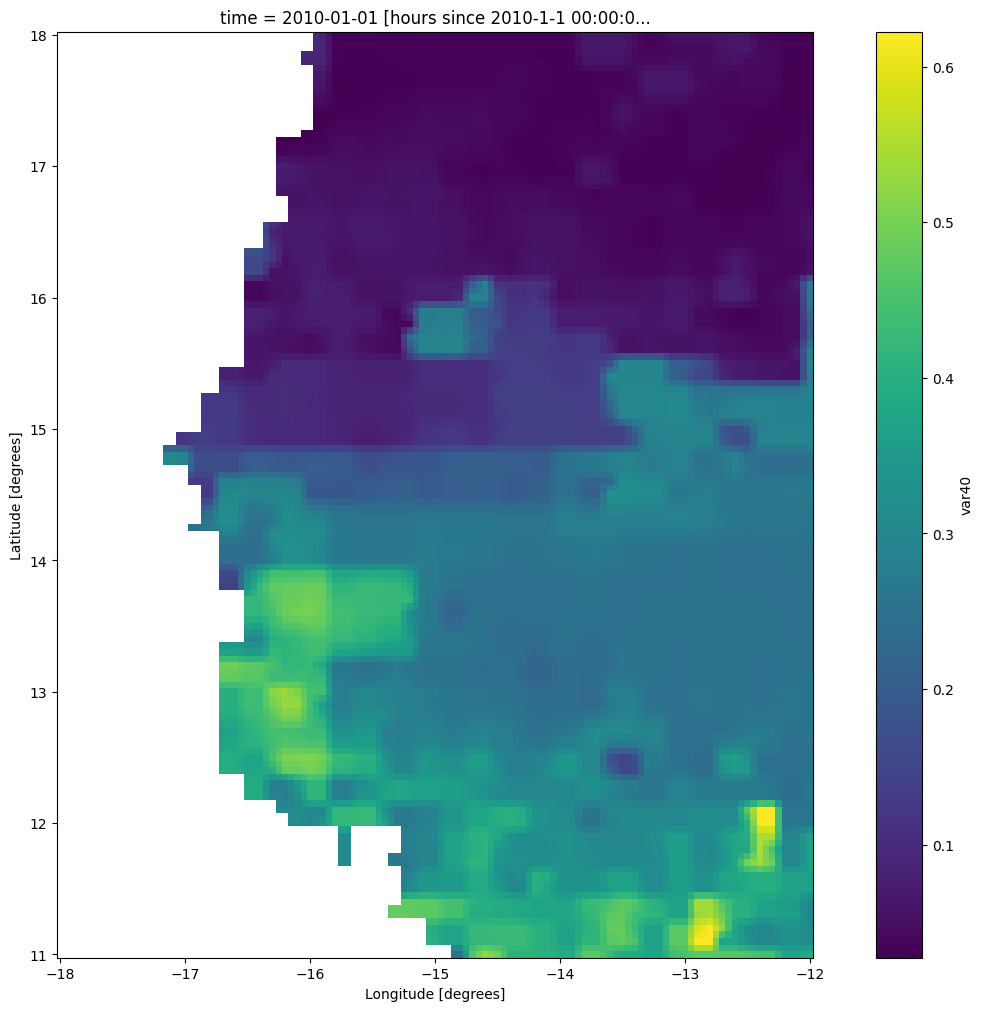

In [18]:
sahel_bbox = {
    "lon_min": -18,
    "lon_max": -12,
    "lat_min": 11,
    "lat_max": 18
}

ds_sahel = ds.sel(
    lon=slice(sahel_bbox["lon_min"], sahel_bbox["lon_max"]),
    lat=slice(sahel_bbox["lat_min"], sahel_bbox["lat_max"])
)
ds_sahel = ds_sahel.rio.write_crs("EPSG:4326", inplace=False)
print(ds_sahel.lat.values[:5], ds_sahel.lat.values[-5:], ds_sahel.lon.values[:5], ds_sahel.lon.values[-5:])
# Calculate aspect ratio for proper geographic display
mean_lat = np.radians(float(ds_sahel['lat'].max()))
aspect_ratio = 1.0 / np.cos(mean_lat)

fig, ax = plt.subplots(figsize=(12, 10), constrained_layout=True)
ds_sahel["var40"].isel(time=0).plot(ax=ax, cmap="viridis")
ax.set_aspect(aspect_ratio)
ax.set_xlabel('Longitude [degrees]')
ax.set_ylabel('Latitude [degrees]')
plt.show()

In [20]:
# load the spatial units

units = gpd.read_parquet("/home/kzakir/dvcube/cdrxclimate/cdr_test/mobility_data/spatial_units_with_lat_lon.parquet")
units

,id,name,zone_category,geometry,norm_id,lon,lat
0,SEN.1.1.1-rural,Dakar-rural,rural,"MULTIPOLYGON (((-17.14005 14.57827, -17.14034 ...",sen.1.1.1,-17.187838,14.751204
1,SEN.10.1.1-rural,Mbane-rural,rural,"MULTIPOLYGON (((-15.83737 16.21078, -15.87214 ...",sen.10.1.1,-15.585999,16.227448
2,SEN.10.1.2-rural,Ndiaye Mberess-rural,rural,"MULTIPOLYGON (((-16.26705 16.0281, -16.24896 1...",sen.10.1.2,-16.093441,16.263351
3,SEN.10.2.1-rural,Cas Cas-rural,rural,"MULTIPOLYGON (((-14.37828 16.01092, -14.44253 ...",sen.10.2.1,-14.229220,16.239571
4,SEN.10.2.2-rural,Gamadji Sarre-rural,rural,"MULTIPOLYGON (((-15.03611 16.01448, -14.99439 ...",sen.10.2.2,-14.684249,16.288648
...,...,...,...,...,...,...,...
146,city-048,Thiès,urban,"MULTIPOLYGON (((-17.00244 14.80395, -17.0009 1...",city-048,-16.926520,14.790789
147,city-049,Tivaouane,urban,"MULTIPOLYGON (((-16.8533 14.93582, -16.8485 14...",city-049,-16.812656,14.965186
148,city-050,Touba,urban,"MULTIPOLYGON (((-15.92335 14.7155, -15.95312 1...",city-050,-15.871611,14.854303
149,city-052,Vélingara,urban,"MULTIPOLYGON (((-14.1644 13.10737, -14.18021 1...",city-052,-14.122209,13.141354


In [66]:
import numpy as np
import shapely

# Adjust these names to match your data
zones = units[
    ["zone_category", "name", "geometry"]
].copy()

# Remove missing, empty and invalid geometries
zones = zones.loc[
    zones.geometry.notna()
    & ~zones.geometry.is_empty
    & zones.geometry.is_valid
].reset_index(drop=True)

print(f"Valid zones: {len(zones)}")

Valid zones: 151


In [67]:
print("Vector CRS:", zones.crs)
print("Raster CRS:", ds_sahel.rio.crs)

Vector CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "scope":

In [68]:
zones

,zone_category,name,geometry
0,rural,Dakar-rural,"MULTIPOLYGON (((-17.14005 14.57827, -17.14034 ..."
1,rural,Mbane-rural,"MULTIPOLYGON (((-15.83737 16.21078, -15.87214 ..."
2,rural,Ndiaye Mberess-rural,"MULTIPOLYGON (((-16.26705 16.0281, -16.24896 1..."
3,rural,Cas Cas-rural,"MULTIPOLYGON (((-14.37828 16.01092, -14.44253 ..."
4,rural,Gamadji Sarre-rural,"MULTIPOLYGON (((-15.03611 16.01448, -14.99439 ..."
...,...,...,...
146,urban,Thiès,"MULTIPOLYGON (((-17.00244 14.80395, -17.0009 1..."
147,urban,Tivaouane,"MULTIPOLYGON (((-16.8533 14.93582, -16.8485 14..."
148,urban,Touba,"MULTIPOLYGON (((-15.92335 14.7155, -15.95312 1..."
149,urban,Vélingara,"MULTIPOLYGON (((-14.1644 13.10737, -14.18021 1..."


In [69]:
stats = ds_sahel["var40"].xvec.zonal_stats(
    zones.geometry,
    x_coords="lon",
    y_coords="lat",
    stats="mean",
    method="exactextract",
    name="zone",
    index=False,
)

stats = stats.rename("METREF_mean")

In [70]:
stats

<xarray.DataArray 'METREF_mean' (zone: 151, time: 5)> Size: 6kB
array([[0.29900203, 0.29672333, 0.29517855, 0.3020176 , 0.30531272],
       [0.05989582, 0.0582466 , 0.05219382, 0.05505296, 0.05492176],
       [0.07170199, 0.0707468 , 0.06810586, 0.06679703, 0.06697384],
       [0.06768691, 0.06797934, 0.06748022, 0.06664189, 0.06701761],
       [0.08524862, 0.09612728, 0.10528926, 0.0910663 , 0.10219291],
       [0.11169616, 0.11467979, 0.11162135, 0.10756857, 0.11349943],
       [0.06081137, 0.06652515, 0.05796617, 0.05735468, 0.06380809],
       [0.06139526, 0.06064739, 0.05806911, 0.0547306 , 0.05643778],
       [0.33134611, 0.32628127, 0.33190338, 0.32576288, 0.32942658],
       [0.32574   , 0.31688183, 0.31614508, 0.31403651, 0.31218589],
       [0.27891827, 0.23793909, 0.23198893, 0.23624968, 0.23319835],
       [0.4211596 , 0.36098538, 0.33916134, 0.34073462, 0.32629296],
       [0.29901814, 0.23927431, 0.23368522, 0.23682815, 0.23073996],
       [0.30355264, 0.26130028, 0.25738142, 0.25828054, 0.2502761 ],
       [0.29666803, 0.23260473, 0.22475197, 0.22863101, 0.22334849],
       [0.36342626, 0.34157569, 0.33903994, 0.33708347, 0.33544595],
       [0.36099457, 0.28389024, 0.27556672, 0.27731581, 0.27096689],
       [0.26148759, 0.2615638 , 0.25907538, 0.25921578, 0.26147356],
       [0.25265317, 0.2523544 , 0.25015135, 0.25098124, 0.25088978],
       [0.24269897, 0.25245498, 0.24207379, 0.23728499, 0.25309193],
...
       [0.05784426, 0.05918743, 0.05312202, 0.05665453, 0.05431576],
       [0.12175249, 0.12191711, 0.11779263, 0.12092308, 0.12351268],
       [0.2339857 , 0.23511983, 0.23308507, 0.24075308, 0.23966616],
       [0.12600803, 0.12544012, 0.12267613, 0.12256253, 0.12532651],
       [0.17497877, 0.16318592, 0.19008005, 0.22230438, 0.24612711],
       [       nan,        nan,        nan,        nan,        nan],
       [0.42199376, 0.42334856, 0.41918247, 0.42154375, 0.42091035],
       [0.29667513, 0.29383871, 0.29179323, 0.30177039, 0.30632702],
       [0.16064542, 0.15223888, 0.14835319, 0.18997998, 0.21125041],
       [0.06092751, 0.06212327, 0.05489695, 0.05702956, 0.05969105],
       [0.0429693 , 0.04371828, 0.0516828 , 0.05180201, 0.05636034],
       [0.30622217, 0.30383787, 0.30211344, 0.30921968, 0.31278112],
       [0.34062132, 0.23527887, 0.22370455, 0.22869722, 0.22046489],
       [0.25481751, 0.25471747, 0.24599439, 0.24624347, 0.25464647],
       [0.28975842, 0.289875  , 0.28974049, 0.28861922, 0.28528324],
       [0.19244911, 0.18594814, 0.18119256, 0.21528484, 0.22809923],
       [0.13558505, 0.13447911, 0.1279807 , 0.13071875, 0.13446808],
       [0.13911513, 0.14352693, 0.19647882, 0.18336561, 0.19420994],
       [0.21738411, 0.20078738, 0.19571032, 0.19578865, 0.20031417],
       [0.44959175, 0.44398424, 0.43791887, 0.44164572, 0.4386717 ]])
Coordinates:
  * zone     (zone) geometry 1kB MULTIPOLYGON (((-17.1400547 14.57827377, -17...
  * time     (time) datetime64[ns] 40B 2010-01-01 2010-01-02 ... 2010-01-05
Indexes:
    zone     GeometryIndex (crs=EPSG:4326)
Attributes:
    code:         40
    table:        228
    institution:  ECMWF

In [72]:
stats = stats.assign_coords(
    zone_id=(
        "zone",
        np.arange(len(zones)),
    ),
    city_name=(
        "zone",
        zones["name"].astype(str).to_numpy(),
    ),
    zone_cat=(
        "zone",
        zones["zone_category"].astype(str).to_numpy(),
    ),
)

In [77]:
stats

<xarray.DataArray 'METREF_mean' (zone: 151, time: 5)> Size: 6kB
array([[0.29900203, 0.29672333, 0.29517855, 0.3020176 , 0.30531272],
       [0.05989582, 0.0582466 , 0.05219382, 0.05505296, 0.05492176],
       [0.07170199, 0.0707468 , 0.06810586, 0.06679703, 0.06697384],
       [0.06768691, 0.06797934, 0.06748022, 0.06664189, 0.06701761],
       [0.08524862, 0.09612728, 0.10528926, 0.0910663 , 0.10219291],
       [0.11169616, 0.11467979, 0.11162135, 0.10756857, 0.11349943],
       [0.06081137, 0.06652515, 0.05796617, 0.05735468, 0.06380809],
       [0.06139526, 0.06064739, 0.05806911, 0.0547306 , 0.05643778],
       [0.33134611, 0.32628127, 0.33190338, 0.32576288, 0.32942658],
       [0.32574   , 0.31688183, 0.31614508, 0.31403651, 0.31218589],
       [0.27891827, 0.23793909, 0.23198893, 0.23624968, 0.23319835],
       [0.4211596 , 0.36098538, 0.33916134, 0.34073462, 0.32629296],
       [0.29901814, 0.23927431, 0.23368522, 0.23682815, 0.23073996],
       [0.30355264, 0.26130028, 0.25738142, 0.25828054, 0.2502761 ],
       [0.29666803, 0.23260473, 0.22475197, 0.22863101, 0.22334849],
       [0.36342626, 0.34157569, 0.33903994, 0.33708347, 0.33544595],
       [0.36099457, 0.28389024, 0.27556672, 0.27731581, 0.27096689],
       [0.26148759, 0.2615638 , 0.25907538, 0.25921578, 0.26147356],
       [0.25265317, 0.2523544 , 0.25015135, 0.25098124, 0.25088978],
       [0.24269897, 0.25245498, 0.24207379, 0.23728499, 0.25309193],
...
       [0.05784426, 0.05918743, 0.05312202, 0.05665453, 0.05431576],
       [0.12175249, 0.12191711, 0.11779263, 0.12092308, 0.12351268],
       [0.2339857 , 0.23511983, 0.23308507, 0.24075308, 0.23966616],
       [0.12600803, 0.12544012, 0.12267613, 0.12256253, 0.12532651],
       [0.17497877, 0.16318592, 0.19008005, 0.22230438, 0.24612711],
       [       nan,        nan,        nan,        nan,        nan],
       [0.42199376, 0.42334856, 0.41918247, 0.42154375, 0.42091035],
       [0.29667513, 0.29383871, 0.29179323, 0.30177039, 0.30632702],
       [0.16064542, 0.15223888, 0.14835319, 0.18997998, 0.21125041],
       [0.06092751, 0.06212327, 0.05489695, 0.05702956, 0.05969105],
       [0.0429693 , 0.04371828, 0.0516828 , 0.05180201, 0.05636034],
       [0.30622217, 0.30383787, 0.30211344, 0.30921968, 0.31278112],
       [0.34062132, 0.23527887, 0.22370455, 0.22869722, 0.22046489],
       [0.25481751, 0.25471747, 0.24599439, 0.24624347, 0.25464647],
       [0.28975842, 0.289875  , 0.28974049, 0.28861922, 0.28528324],
       [0.19244911, 0.18594814, 0.18119256, 0.21528484, 0.22809923],
       [0.13558505, 0.13447911, 0.1279807 , 0.13071875, 0.13446808],
       [0.13911513, 0.14352693, 0.19647882, 0.18336561, 0.19420994],
       [0.21738411, 0.20078738, 0.19571032, 0.19578865, 0.20031417],
       [0.44959175, 0.44398424, 0.43791887, 0.44164572, 0.4386717 ]])
Coordinates:
  * zone       (zone) geometry 1kB MULTIPOLYGON (((-17.1400547 14.57827377, -...
    zone_id    (zone) int64 1kB 0 1 2 3 4 5 6 7 ... 144 145 146 147 148 149 150
    city_name  (zone) object 1kB 'Dakar-rural' 'Mbane-rural' ... 'Ziguinchor'
    zone_cat   (zone) object 1kB 'rural' 'rural' 'rural' ... 'urban' 'urban'
  * time       (time) datetime64[ns] 40B 2010-01-01 2010-01-02 ... 2010-01-05
Indexes:
    zone     GeometryIndex (crs=EPSG:4326)
Attributes:
    code:         40
    table:        228
    institution:  ECMWF

In [78]:
print(np.unique(stats["zone_cat"].values))

['rural' 'urban']


In [86]:
urban_stats = stats.where(
    stats["zone_cat"] == "rural",
    drop=True,
)

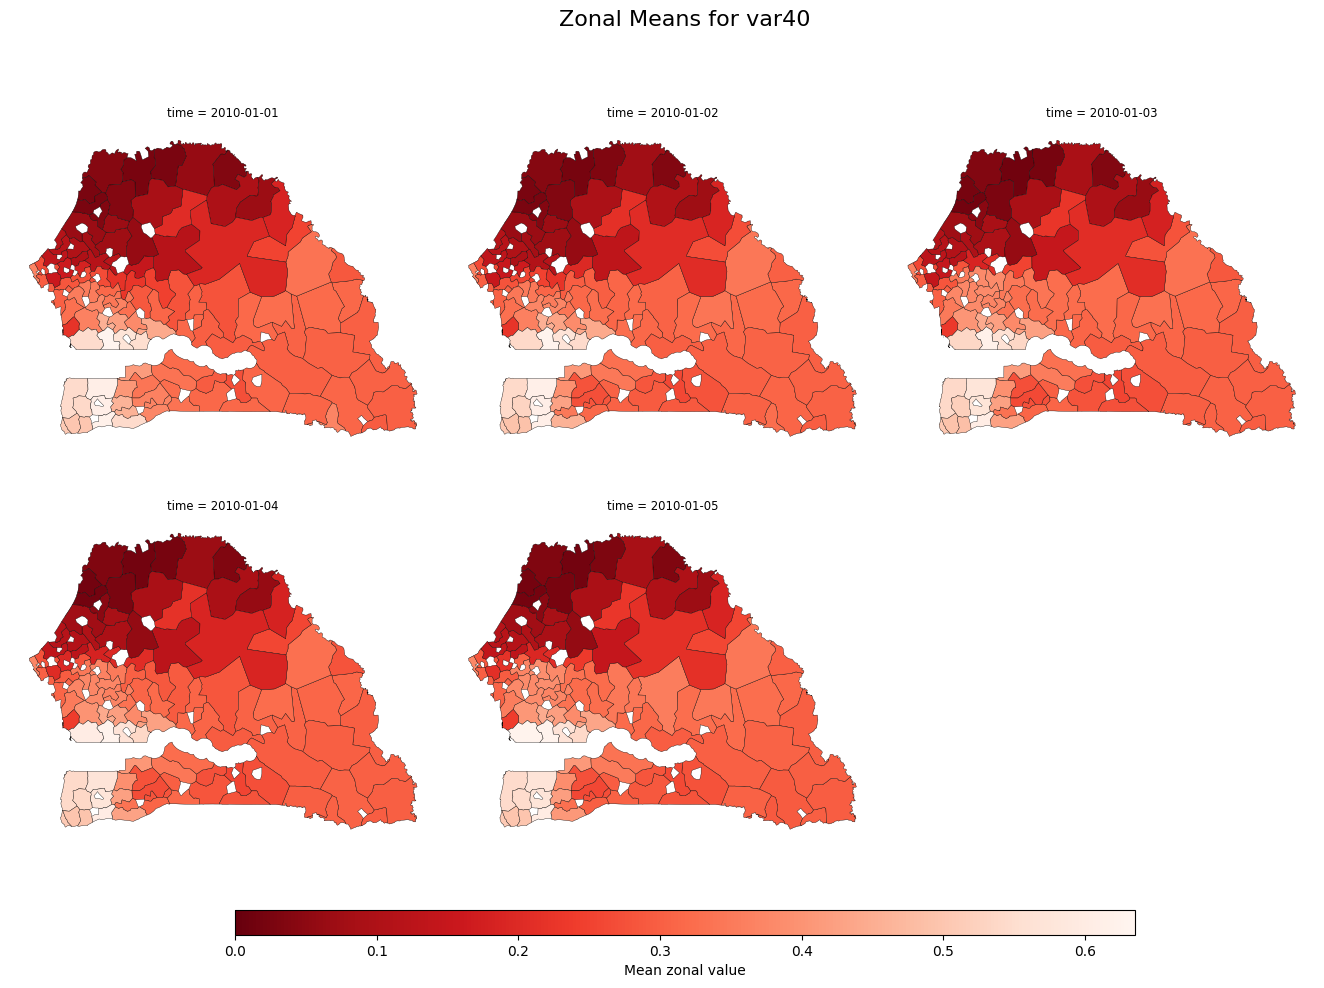

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


plot_data = urban_stats.isel(time=slice(0, 6))

fig, axes = plot_data.xvec.plot(
    col="time",
    col_wrap=3,
    cmap="Reds_r",
    legend=False,  # removes the default vertical colorbar
    figsize=(18, 10),
    vmin=float(stats.min(skipna=True).compute()),
    vmax=float(stats.max(skipna=True).compute()),
    edgecolor="black",
    linewidth=0.25,
)

# Convert axes to a simple list
map_axes = list(np.atleast_1d(axes).ravel())

# Force-delete every additional axis created by Xvec/GeoPandas.
# A default vertical colorbar is normally stored as an extra axis.
for extra_axis in list(fig.axes):
    if extra_axis not in map_axes:
        fig.delaxes(extra_axis)

# Remove map axes and hide empty panels
for axis in map_axes:
    if axis.get_visible():
        axis.set_axis_off()

# Reserve space at the bottom
fig.subplots_adjust(
    bottom=0.13,
    hspace=0.10,
    wspace=0.03,
)

# Build a clean colorbar object using the same scale as the maps
mappable = ScalarMappable(
    norm=Normalize(vmin=vmin, vmax=vmax),
    cmap="Reds_r",
)

mappable.set_array([])

# Add a dedicated horizontal colorbar
cbar_ax = fig.add_axes(
    [
        0.25,   # left
        0.055,  # bottom
        0.50,   # width
        0.025,  # height
    ]
)

colorbar = fig.colorbar(
    mappable,
    cax=cbar_ax,
    orientation="horizontal",
)

colorbar.set_label("Mean zonal value")

fig.suptitle(
    "Zonal Means for var40",
    fontsize=16,
    y=0.98,
)

plt.show()

In [22]:
aggregated = ds_sahel.var41.xvec.zonal_stats(
    units.geometry, x_coords= "lon", y_coords="lat", 
    # stats = "mean",
    method="exactextract"
)
aggregated

<xarray.DataArray (geometry: 151, time: 5)> Size: 6kB
array([[0.3388682 , 0.33700498, 0.33548354, 0.33555902, 0.33522186],
       [0.32522375, 0.32441933, 0.32314056, 0.32241277, 0.32153231],
       [0.32395848, 0.32310297, 0.32243999, 0.32169903, 0.32106312],
       [0.3004294 , 0.29974568, 0.30155423, 0.30055674, 0.3004397 ],
       [0.35742151, 0.35815975, 0.36259993, 0.36146073, 0.36497914],
       [0.20447932, 0.20436879, 0.206871  , 0.20670908, 0.20824045],
       [0.34714902, 0.34741717, 0.34631749, 0.34537051, 0.34807839],
       [0.33364575, 0.33295088, 0.3323425 , 0.33156641, 0.33089947],
       [0.55563125, 0.55192656, 0.55660523, 0.55847604, 0.56001203],
       [0.54998168, 0.54812765, 0.5470399 , 0.54705504, 0.54538931],
       [0.57067242, 0.56402944, 0.55956248, 0.56126365, 0.56169596],
       [0.61863479, 0.60172793, 0.59889748, 0.59749296, 0.5936833 ],
       [0.56560737, 0.55603099, 0.55105594, 0.55085045, 0.54821871],
       [0.5208559 , 0.51244648, 0.50845879, 0.51094381, 0.509117  ],
       [0.59933825, 0.59027085, 0.58442494, 0.5832518 , 0.58076521],
       [0.6038543 , 0.59730095, 0.59453457, 0.5938377 , 0.59117446],
       [0.63536   , 0.61166525, 0.60985403, 0.60889783, 0.60573021],
       [0.33348161, 0.33276351, 0.33251442, 0.33317785, 0.33219473],
       [0.33311935, 0.33270471, 0.33224435, 0.33286429, 0.33167332],
       [0.30521811, 0.30471811, 0.30475386, 0.30587939, 0.30473028],
...
       [0.34020707, 0.33960759, 0.33976084, 0.33929074, 0.33884276],
       [0.22278773, 0.22253581, 0.22275589, 0.22331401, 0.22262642],
       [0.45946602, 0.45870819, 0.45817415, 0.45807154, 0.45784292],
       [0.15414023, 0.1531558 , 0.15417814, 0.15417814, 0.15342093],
       [0.14694147, 0.14477274, 0.14505993, 0.14465382, 0.14452185],
       [       nan,        nan,        nan,        nan,        nan],
       [0.60842825, 0.60565875, 0.60957701, 0.60794402, 0.60634817],
       [0.33202345, 0.33005749, 0.32852363, 0.32853621, 0.32818669],
       [0.14330348, 0.14110965, 0.14119008, 0.14057618, 0.13998995],
       [0.32920991, 0.32785691, 0.32626937, 0.32509806, 0.32432867],
       [0.32215676, 0.32149272, 0.32103085, 0.3203893 , 0.31988685],
       [0.34620818, 0.34426419, 0.3426898 , 0.34273747, 0.34239315],
       [0.63123739, 0.61653237, 0.61075181, 0.61091113, 0.60816877],
       [0.3428651 , 0.34196734, 0.34003005, 0.34036591, 0.33858866],
       [0.43526065, 0.43339599, 0.43157607, 0.43085779, 0.42945306],
       [0.18597991, 0.18397158, 0.18290683, 0.18259347, 0.18219283],
       [0.14588534, 0.14400043, 0.14268845, 0.14154008, 0.14090042],
       [0.1525416 , 0.15064383, 0.15037286, 0.14995847, 0.14970148],
       [0.49453674, 0.49447214, 0.49377752, 0.49682923, 0.4976557 ],
       [0.59076608, 0.58835059, 0.58630865, 0.58515769, 0.5829329 ]])
Coordinates:
  * geometry  (geometry) geometry 1kB MULTIPOLYGON (((-17.1400547 14.57827377...
  * time      (time) datetime64[ns] 40B 2010-01-01 2010-01-02 ... 2010-01-05
Indexes:
    geometry  GeometryIndex (crs=EPSG:4326)
Attributes:
    code:         41
    table:        228
    institution:  ECMWF

In [33]:
# change tiime dimension to datetime
aggregated['time'] = pd.to_datetime(aggregated['time'].values)

In [23]:
print(aggregated.dims)

('geometry', 'time')


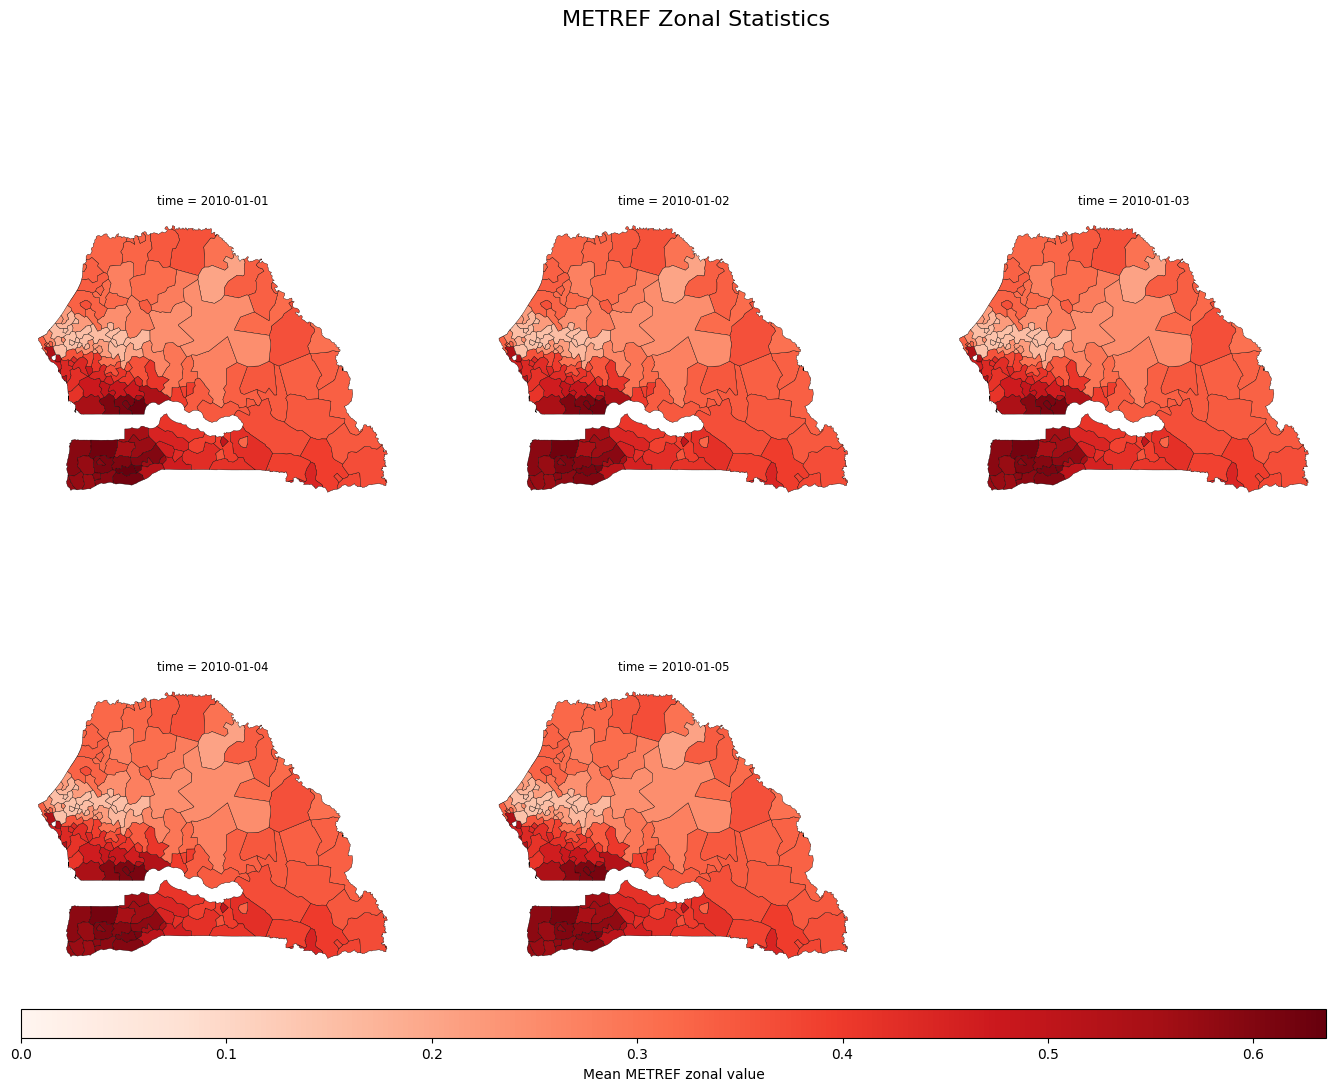

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# Select the time steps
plot_data = aggregated.isel(time=slice(0, 6))

# Giving the DataArray a name is helpful
if plot_data.name is None:
    plot_data = plot_data.rename("METREF")

# Common colour range for every panel
vmin = 0
vmax = float(plot_data.max(skipna=True).compute())

# Do not pass geometry="geometry"
fig, axes = plot_data.xvec.plot(
    col="time",
    col_wrap=3,
    cmap="Reds",
    legend=False,
    figsize=(18, 12),
    vmin=vmin,
    vmax=vmax,
    edgecolor="black",
    linewidth=0.25,
)

# xvec returns an array of Matplotlib axes
axes_flat = np.atleast_1d(axes).ravel()

# Number of maps actually used
n_panels = plot_data.sizes["time"]
used_axes = axes_flat[:n_panels]

# Hide unused axes
for axis in axes_flat[n_panels:]:
    axis.set_visible(False)
for extra_axis in list(fig.axes):
    if extra_axis not in used_axes:
        fig.delaxes(extra_axis)
# Optional map formatting
for axis in used_axes:
    axis.set_axis_off()

# Find the polygon collection used for colouring
mappable = next(
    collection
    for axis in used_axes
    for collection in axis.collections
    if collection.get_array() is not None
)

# Add one shared horizontal colourbar
colorbar = fig.colorbar(
    mappable,
    ax=used_axes.tolist(),
    orientation="horizontal",
    fraction=0.035,
    pad=0.04,
    aspect=45,
)

colorbar.set_label("Mean METREF zonal value")

fig.suptitle(
    "METREF Zonal Statistics",
    fontsize=16,
    y=0.97,
)

plt.show()

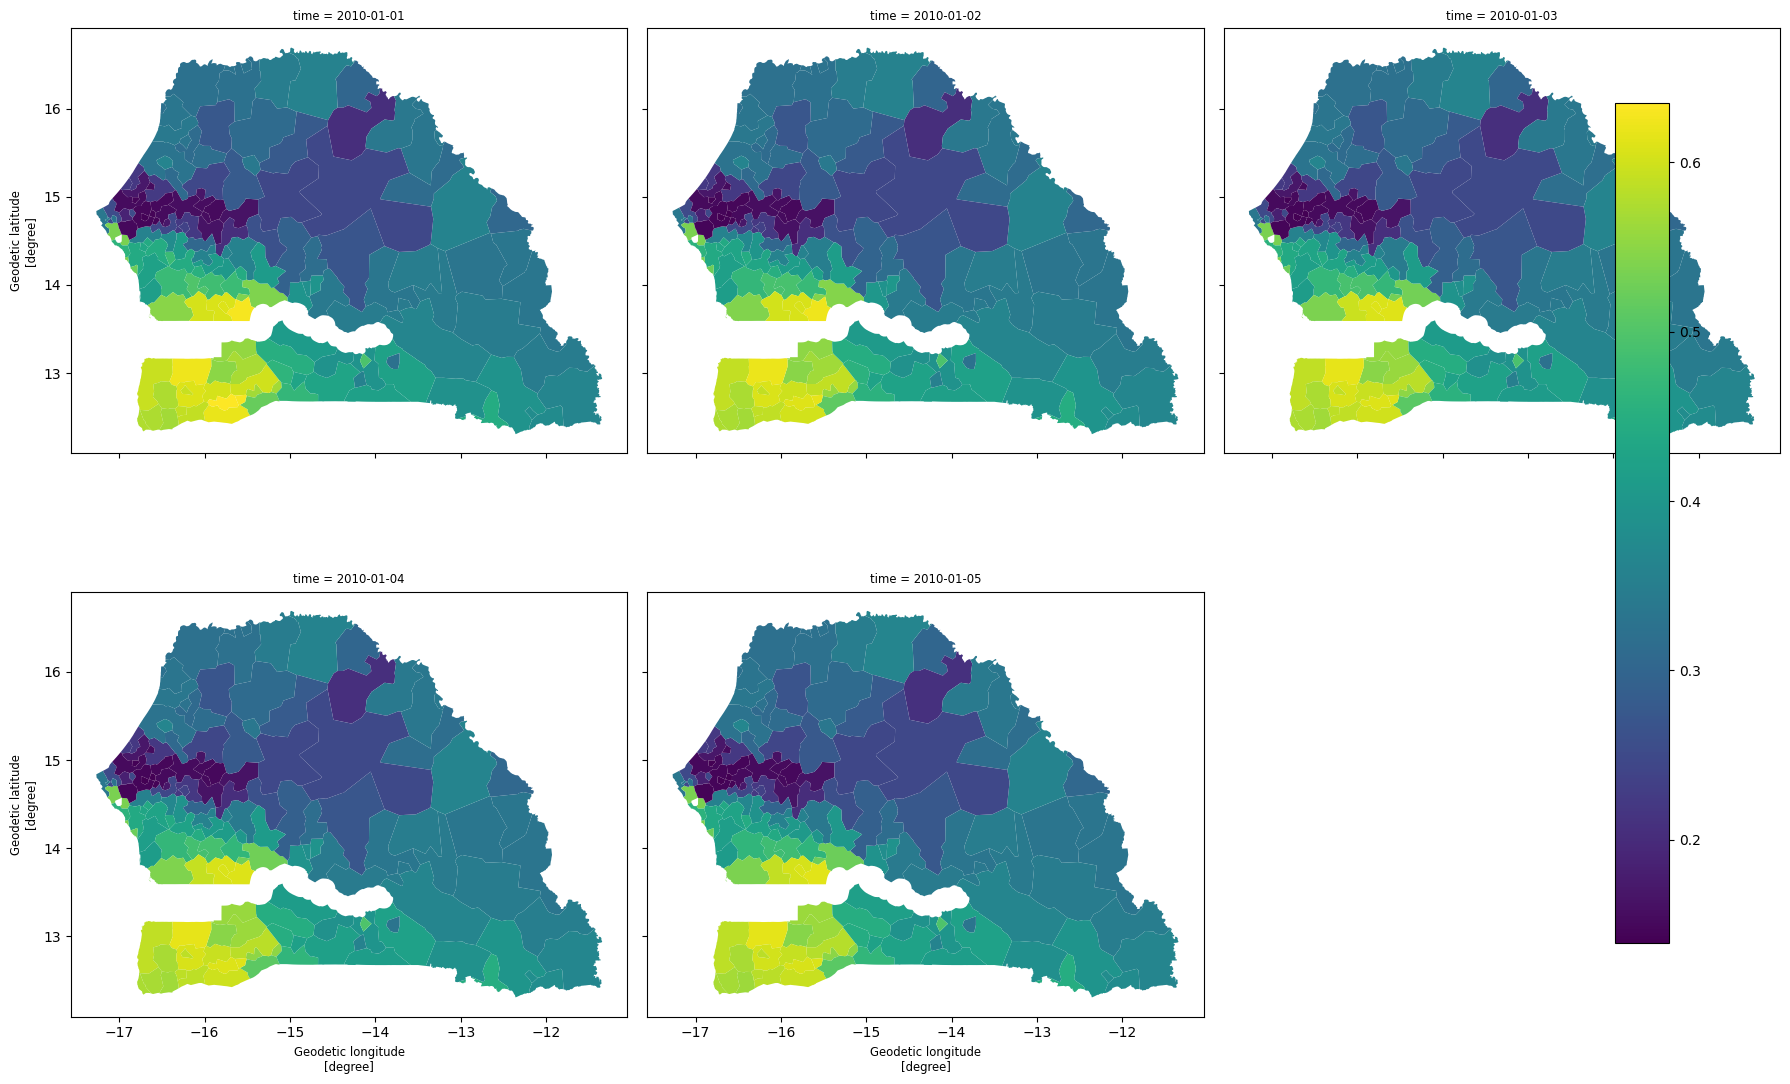

In [53]:
aggregated.isel(time=slice(0, 6)).xvec.plot(
    col="time",
    col_wrap=3,
    cmap="viridis",
    legend=False,
    figsize=(18, 12),
)
# have the cbar horiztonal
plt.tight_layout()
plt.show()